# 📊 Full Exploratory Data Analysis & Feature Evaluation
This notebook performs EDA on the final machine learning feature table engineered via the BigQuery pipeline. It validates feature distributions, checks class balance, evaluates multicollinearity, benchmarks baseline feature importances, and carries out feature screening.

<div style="background-color: #fef7e0; border-left: 4px solid #b06000; color: #b06000; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>⚠️ Dependency Note:</strong> Requires appropriate VM service account BigQuery permissions in IAM (Admin, or Job User & Data Viewer roles) to query <code>instacart-ml-model.ml_model_feature_table</code>.
</div>

## Overview
1. Imports, BigFrames Data Loading, & 10% User Sampling
2. Data Types, Missing Values, Duplicates, Descriptive Statistics, & Class Balance
3. Feature Distributions (Histograms and Box Plots)
4. Correlation Heatmap & Multicollinearity Check
5. Cumulative Gain & Baseline LightGBM Importance Verification

### 1. Imports, BigFrames Data Loading, 10% User Sample
Perform imports, load big query ml features table into a BigFrame, and extract a 10% user sample

<div style="background-color: #e8f0fe; border-left: 4px solid #1a73e8; color: #1c3d5a; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>🛠️ Strategy:</strong> Due to the almost 20M row scale of the feature tale, I leverage <code>BigFrames</code> to keep execution in the Big Query engine when possible. Additionally, I take a reproducible 10% user sample to work with locally for faster visualization and modeling.
</div>

In [1]:
import bigframes.pandas as bpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ndcg_score
import warnings
warnings.filterwarnings('ignore')
import optuna
import xgboost as xgb
import lightgbm as lgb
from statsmodels.stats.outliers_influence import variance_inflation_factor
from joblib import Parallel, delayed
import pyarrow as pa

In [2]:
# 1. Initialize BigQuery connection strings
bpd.options.bigquery.project = "instacart-ml-model"
bpd.options.bigquery.location = "US"

# Load data into BigFrame
bf_full = bpd.read_gbq("instacart-ml-model.ml_model_feature_table.final_ml_features_table")

# 1. Get unique users
unique_users = bf_full[['user_id']].drop_duplicates()

# 2. Obtain reproducible 10% sample
sample_users = unique_users.sample(frac=0.10, random_state=42)

# 3. Merge to bf_full to create 10% sample
df_sample = bf_full.merge(sample_users, on='user_id', how='inner').to_pandas()


print(f"Full data shape: {bf_full.shape}")
print(f"Sample data shape: {df_sample.shape}")

Full data shape: (18931851, 39)
Sample data shape: (1803821, 39)


### 2. Data Types, Missing Values, Duplicates, Descriptive Statistics, and Class Balance

<div style="background-color: #e6f4ea; border-left: 4px solid #137333; color: #137333; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>💡 Key Insights & Preprocessing Strategy:</strong> 
    <ul>
        <li><strong>Feature Pruning:</strong> High-cardinality ID columns (except <code>department_id</code> and <code>aisle_id</code>) and structural artifacts like <code>anchor_order_number</code> will be dropped prior to modeling.</li>
        <li><strong>Data Type Casting:</strong> Convert categorical identifiers and cyclical time components (<code>aisle_id</code>, <code>department_id</code>, <code>label_time_of_day</code>, <code>label_order_dow</code>) to category dtypes.</li>
        <li><strong>Missing Values:</strong> Nulls are safely isolated to <code>user_product_cart_position_last_order</code>, accurately reflecting items omitted from a user's final basket history.</li>
        <li><strong>Class Imbalance:</strong> The label target (<code>label_reordered</code>) exhibits heavy class sparsity (~9% positive class). While tree-based models (LightGBM/XGBoost) handle imbalance natively via ranking metrics, balancing strategies should be evaluated if precision-recall tradeoffs require tuning.</li>
    </ul>
</div>

In [3]:
bf_full.dtypes

user_id                                                   Int64
anchor_order_id                                           Int64
anchor_order_number                                       Int64
candidate_product_id                                      Int64
department_id                                             Int64
aisle_id                                                  Int64
anchor_days_since_first_order                             Int64
label_order_id                                            Int64
label_order_number                                        Int64
label_reordered                                           Int64
label_order_dow                                           Int64
label_order_hour_of_day                                   Int64
label_days_since_prior_order                              Int64
label_time_of_day                               string[pyarrow]
label_days_since_first_order                              Int64
user_avg_days_between_orders            

In [4]:
null_count = bf_full.isnull().sum().to_pandas()
null_df = pd.DataFrame(null_count)

null_df.head(38)

,0
user_id,0
anchor_order_id,0
anchor_order_number,0
candidate_product_id,0
department_id,0
aisle_id,0
anchor_days_since_first_order,0
label_order_id,0
label_order_number,0
label_reordered,0


In [5]:
duplicated_count = bf_full.duplicated().sum()

print("Duplicate Check")
print(duplicated_count)

Duplicate Check
0


In [6]:
exclude_cols = ['user_id', 'label_order_id', 'label_order_number', 'candidate_product_id',
                'anchor_order_id', 'anchor_order_number', 'candidate_product_id', 'department_id', 'aisle_id']

bf_full.drop(columns = exclude_cols).describe()

,anchor_days_since_first_order,label_reordered,label_order_dow,label_order_hour_of_day,label_days_since_prior_order,label_days_since_first_order,user_avg_days_between_orders,user_distinct_product_count,user_organic_affinity_ratio,user_avg_basket_size,...,user_product_reorder_concentration,user_product_order_penetration_ratio,user_product_consecutive_order_skips,user_product_last3order_streak,label_user_product_days_since_last_purchased,user_prod_avg_days_between_purchases,user_product_nearing_reorder_ratio,days_since_last_ordered_vs_user_pace_ratio,user_product_day_of_week_affinity,user_product_time_of_day_affinity
count,18931851.0,18931851.0,18931851.0,18931851.0,18931851.0,18931851.0,18931851.0,18931851.0,18931851.0,18931851.0,...,18931851.0,18931851.0,18931851.0,18931851.0,18931851.0,18931851.0,18931851.0,18931851.0,18931851.0,18931851.0
mean,185.270368,0.087617,2.77981,13.36374,8.433459,193.703827,8.4869,122.945708,0.32619,12.233859,...,0.012583,0.126553,11.438675,0.181354,80.136415,586.403724,0.763289,12.10073,0.152599,0.332371
std,88.248429,0.282738,2.053886,4.217243,7.586835,87.818111,4.736124,74.615533,0.190091,5.833696,...,0.03317,0.146793,13.962244,0.541318,73.666583,463.918088,16.32752,13.707539,0.335941,0.438887
min,1.0,0.0,0.0,0.0,0.0,2.0,0.125,1.0,0.0,1.0,...,0.0,0.010101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,112.0,0.0,1.0,10.0,3.0,123.0,5.030769,68.0,0.168539,8.136364,...,0.0,0.037037,2.0,0.0,21.0,54.0,0.065065,2.708333,0.0,0.0
50%,182.0,0.0,3.0,13.0,6.0,191.0,7.289474,107.0,0.350318,11.272727,...,0.0,0.074468,6.0,0.0,56.0,999.0,0.178178,7.12069,0.0,0.0
75%,256.0,0.0,5.0,16.0,10.0,264.0,10.8,160.0,0.467742,15.210526,...,0.011834,0.155556,16.0,0.0,118.0,999.0,0.711111,16.271186,0.0,1.0
max,365.0,1.0,6.0,23.0,30.0,365.0,30.0,616.0,1.0,63.8,...,1.0,1.0,98.0,3.0,365.0,999.0,999.0,105.426829,1.0,1.0


In [7]:
bf_full['user_prod_avg_days_between_purchases'].describe()

count    18931851.0
mean     586.403724
std      463.918088
min             0.0
25%            54.0
50%           999.0
75%           999.0
max           999.0
Name: user_prod_avg_days_between_purchases, dtype: Float64

In [8]:
bf_full['label_reordered'].value_counts(normalize=True).round(3)

label_reordered
0    0.912
1    0.088
Name: proportion, dtype: Float64

<div style="background-color: #e6f4ea; border-left: 4px solid #137333; color: #137333; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>💡 Key Insights:</strong> 
    <ul>
        <li><strong>Prune ID Columns:</strong> High-cardinality ID columns (except <code>department_id</code> and <code>aisle_id</code>) should be dropped prior to modeling.</li>
        <li><strong>Missing Values:</strong> Nulls are isolated to <code>user_product_cart_position_last_order</code>, accurately reflecting items omitted from a user's last order.</li>
        <li><strong>Duplicates:</strong> There are no duplicates in the data.</li>
        <li><strong>Class Imbalance:</strong> The label (<code>label_reordered</code>) exhibits class imbalance (~9% positive class). While tree-based models (LightGBM/XGBoost) handle imbalance well natively, balancing strategies should be considered.</li>
    </ul>
</div>

### 3. Feature Distributions (Histograms and Box Plots)
Histograms and boxplots for key features

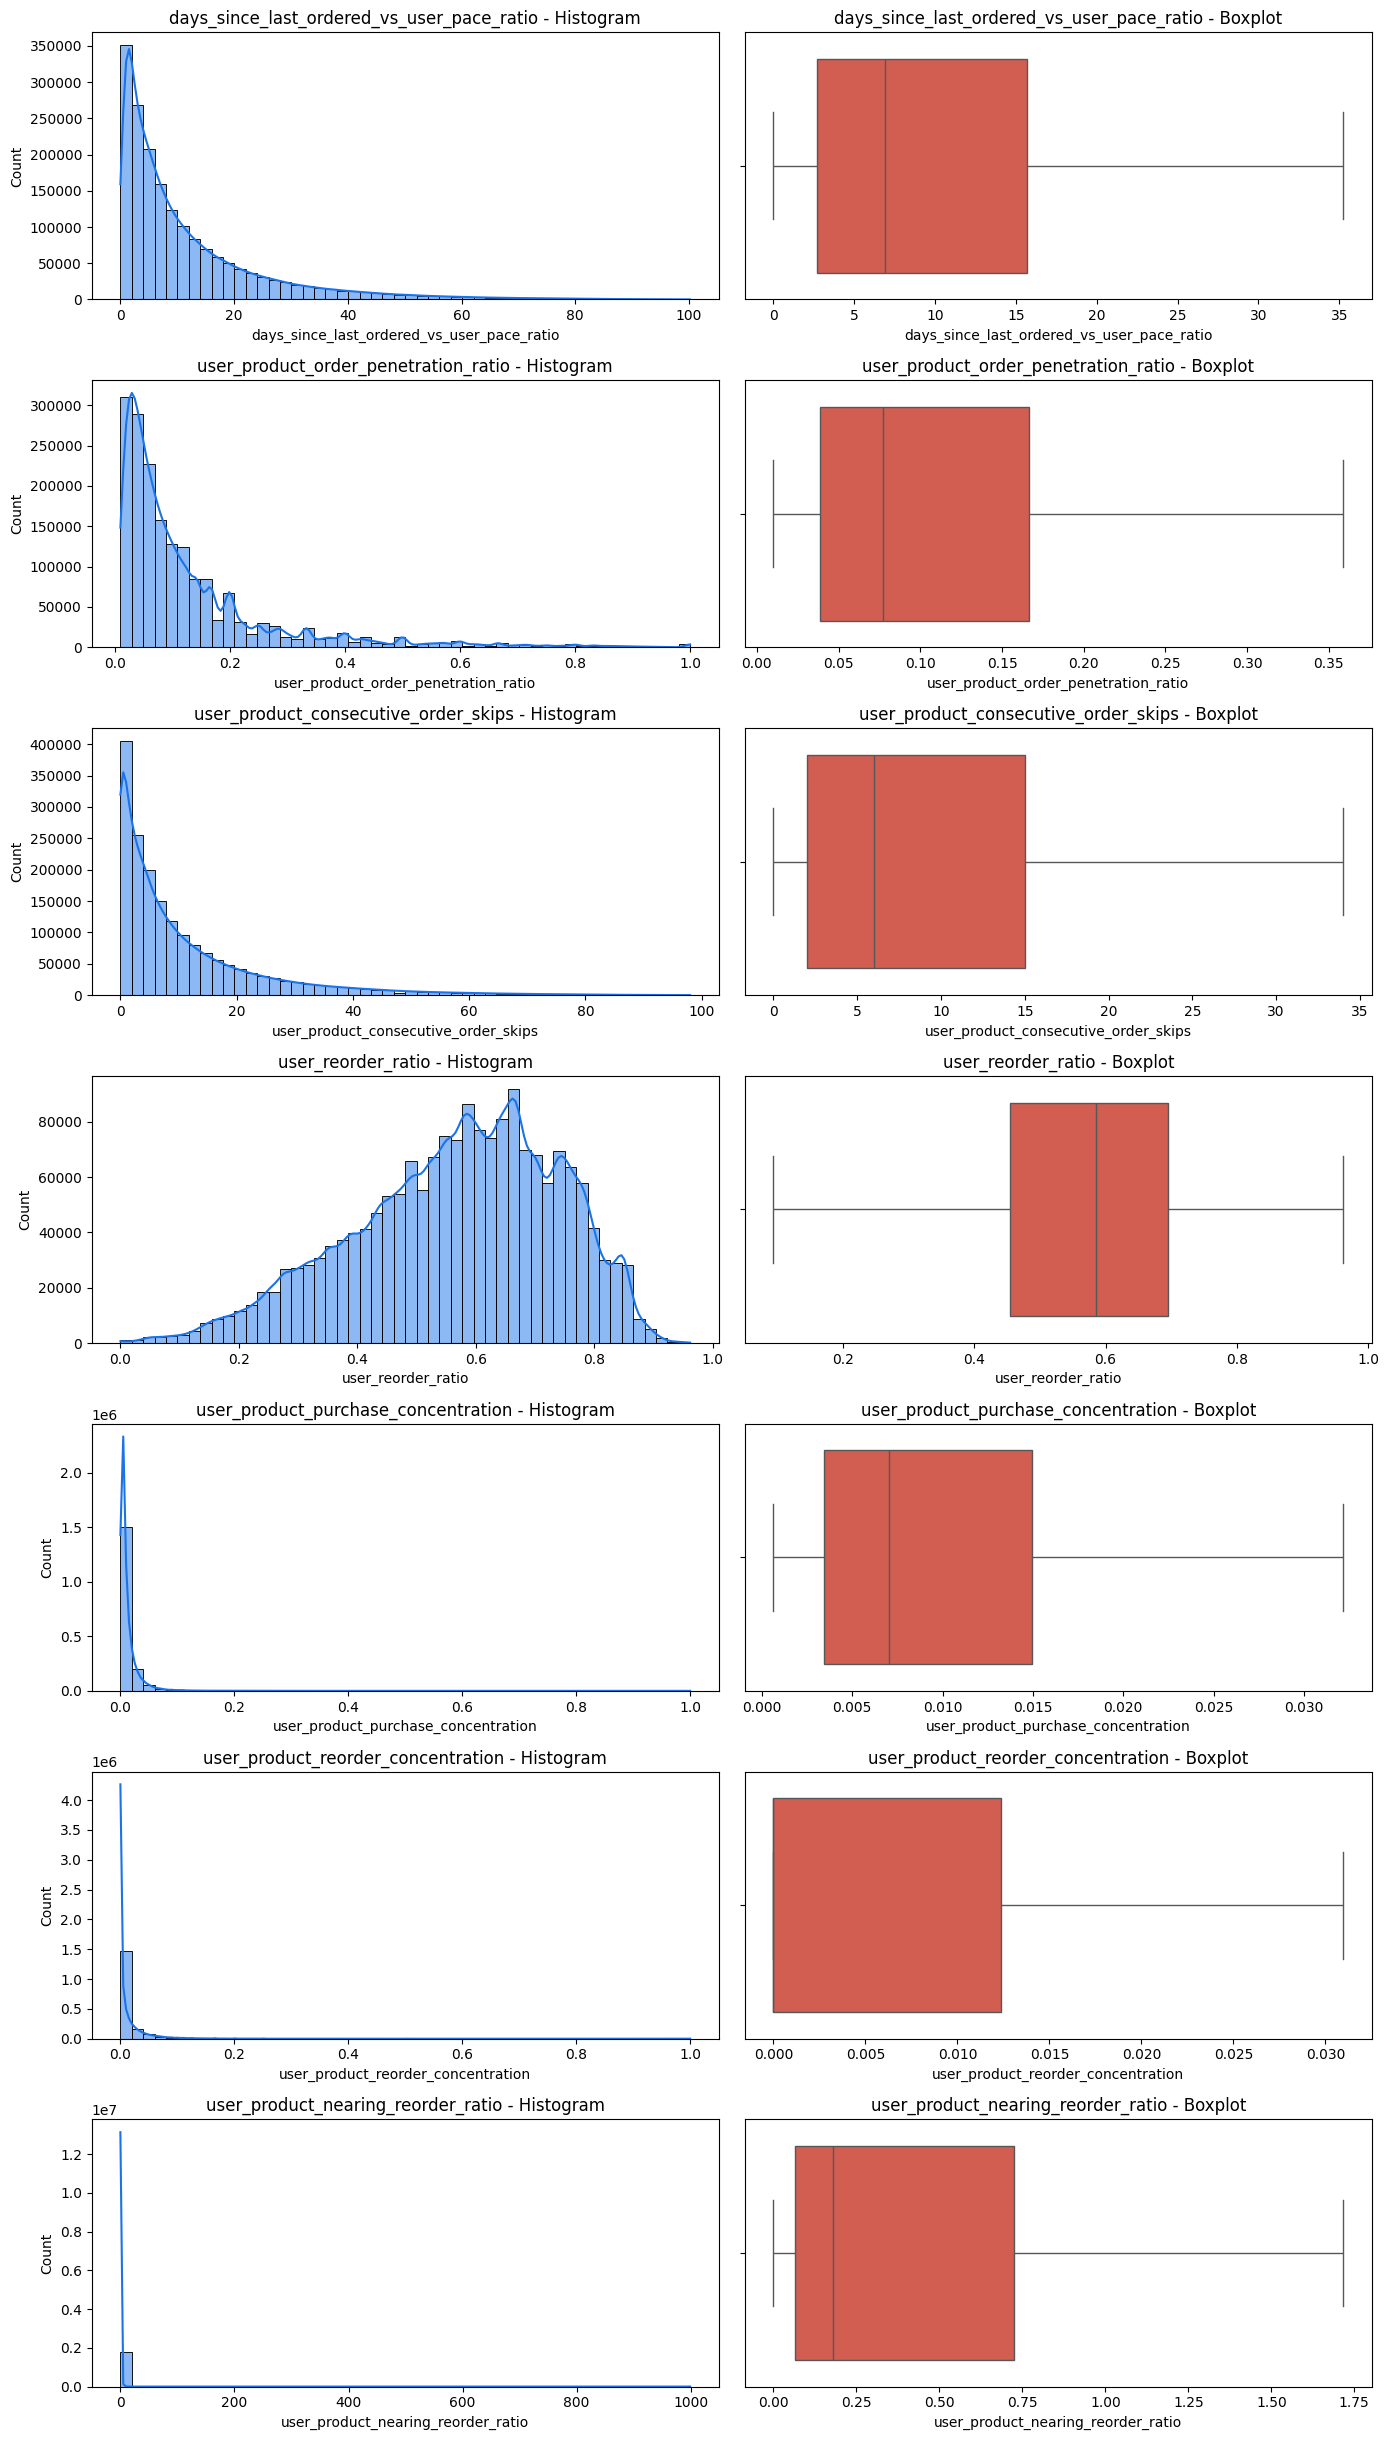

In [9]:
cols = [
    'days_since_last_ordered_vs_user_pace_ratio', 
    'user_product_order_penetration_ratio',
    'user_product_consecutive_order_skips',
    'user_reorder_ratio',
    'user_product_purchase_concentration',
    'user_product_reorder_concentration',
    'user_product_nearing_reorder_ratio']

fig, axes = plt.subplots(len(cols), 2, figsize=(14, len(cols) * 3.5))

for i, col in enumerate(cols):
    # Left Column: Continuous distribution histograms
    sns.histplot(df_sample[col], bins=50, kde=True, ax=axes[i, 0], color='#1a73e8')
    axes[i, 0].set_title(f'{col} - Histogram')
    
    # Right Column: Whisker box plots to check outlier thresholds
    sns.boxplot(x=df_sample[col], ax=axes[i, 1], color='#e74c3c', showfliers = False)
    axes[i, 1].set_title(f'{col} - Boxplot')

plt.tight_layout()
plt.show()


<div style="background-color: #e6f4ea; border-left: 4px solid #137333; color: #137333; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>💡 Key Insight (User-Product Dynamics):</strong> 
    <ul>
        <li><strong>Staples vs. Exploration:</strong> Penetration, concentration, and reorder metrics show that at the individual customer level, a shopper's basket splits into two distinct categories: a small set of staple items bought in most orders, and a large tail of exploratory or one-off items.</li>
        <li><strong>Behavioral Consistency:</strong> The boxplots show that these behavioral metrics have expected middle ranges for customer habits. This will give the ml models clean patterns to learn from.</li>
    </ul>
</div>

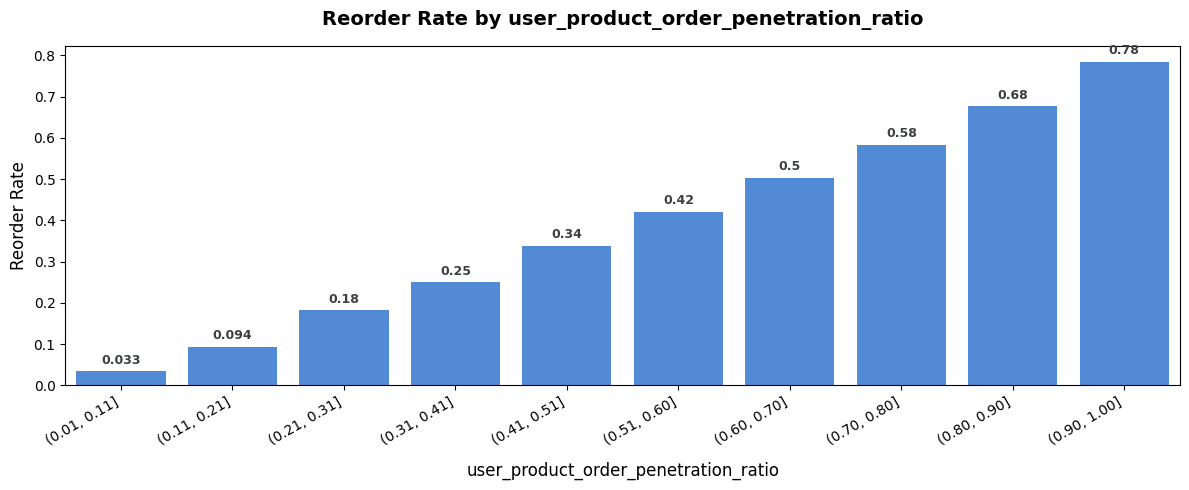

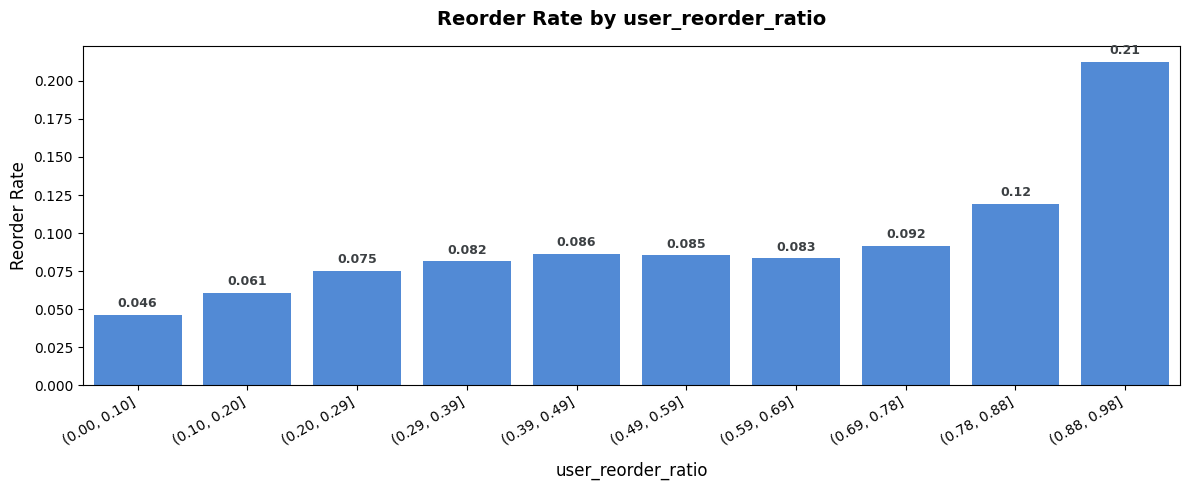

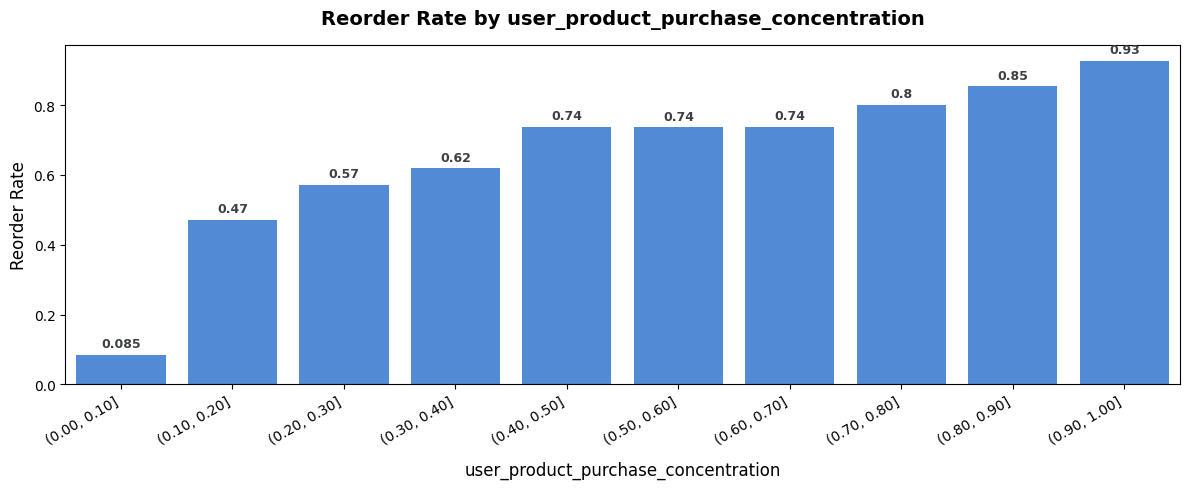

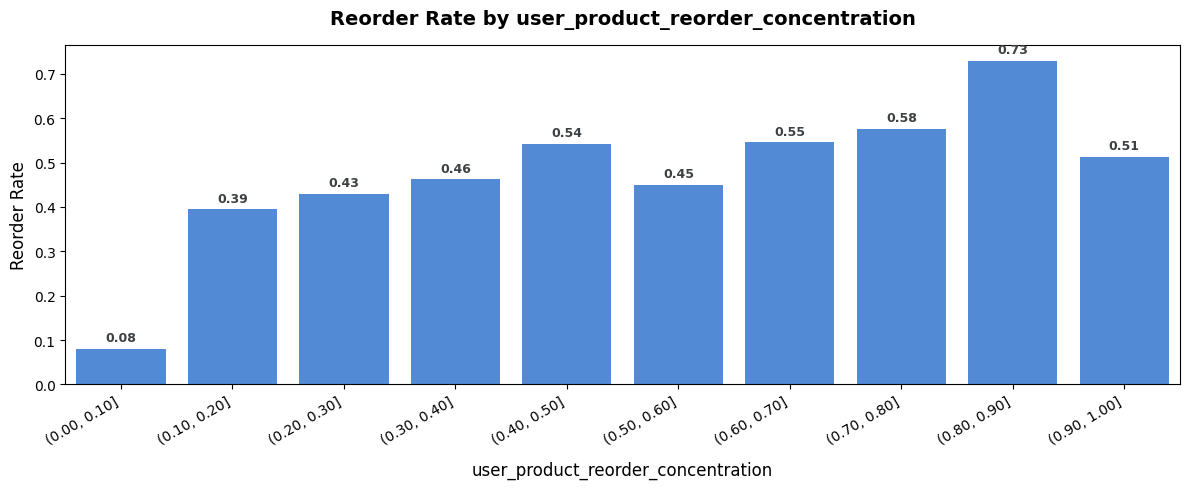

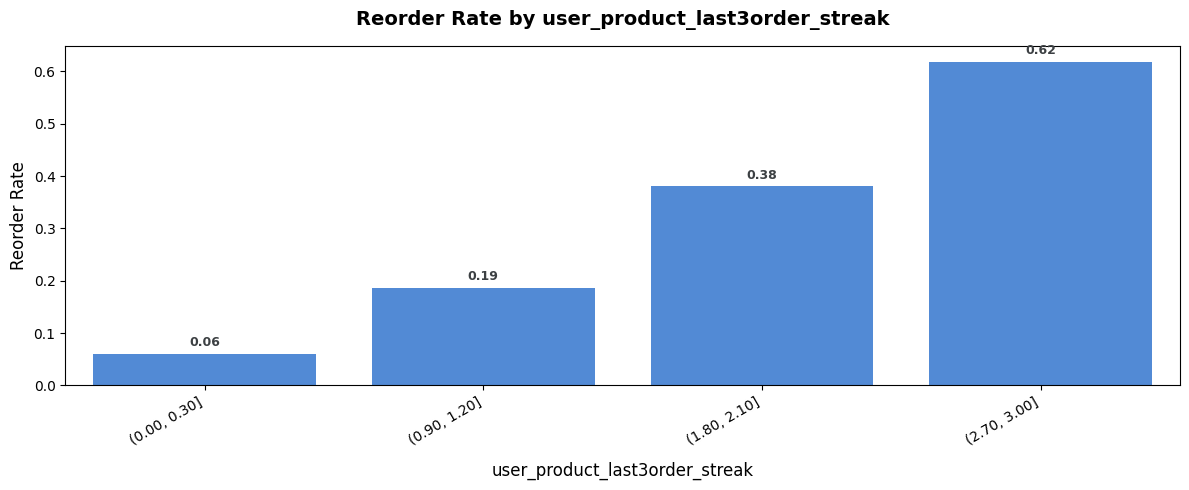

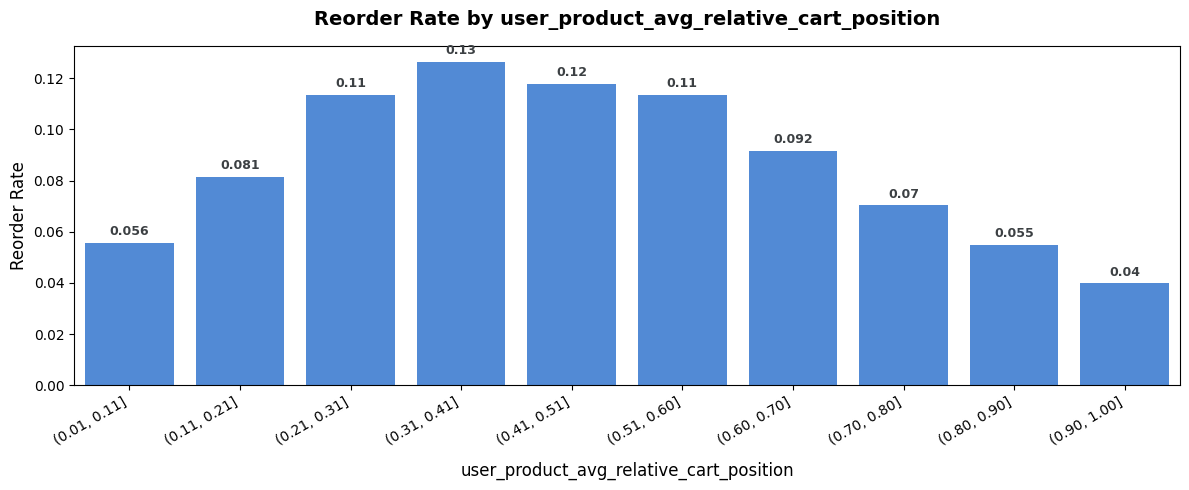

In [10]:
cols = [
    'user_product_order_penetration_ratio',
    'user_reorder_ratio',
    'user_product_purchase_concentration',
    'user_product_reorder_concentration',
    'user_product_last3order_streak',
    'user_product_avg_relative_cart_position'
]

label = ['label_reordered']

# Set theme and edge colors
#sns.set_theme(style="whitegrid")
#plt.rcParams['patch.force_edgecolor'] = True
#plt.rcParams['patch.edgecolor'] = '#333333'

#Due to binning before plotting, the full data set can be used for the bar plots.
#Create a copy to avoid manipulating the orignal data set. Keep only cols and label in the copy

select_cols = cols + label
bf_copy = bf_full[select_cols].copy()

# 3. Loop through columns and construct bar plot
for col in cols:
    
    # Create 10 equal sized bins. Not using bpd.cut due to issues working with STRUCT object it creates for the bins
    stats_summary = bf_copy[col].describe().to_pandas()
    col_min = float(stats_summary.loc['min'])
    col_max = float(stats_summary.loc['max'])

    bin_width = (col_max - col_min) / 10
  
    #Create bin text labels
    bin_edges = np.linspace(col_min, col_max, 11)
    bin_labels = [f"({bin_edges[i]:.2f}, {bin_edges[i+1]:.2f}]" for i in range(10)]

    binned_sql = f"""
    WITH calculated_bins AS (
        SELECT 
            label_reordered,
            FLOOR((`{col}` - {col_min}) / {bin_width}) AS bin_id
        FROM `instacart-ml-model.ml_model_feature_table.final_ml_features_table`
    )
    SELECT 
        CASE 
            WHEN bin_id < 0 THEN 0
            WHEN bin_id >= 10 THEN 9
            ELSE CAST(bin_id AS INT64)
        END AS bin_id,
        AVG(label_reordered) AS label_reordered
    FROM calculated_bins
    GROUP BY bin_id
    """
    
    df_bin_agg = bpd.read_gbq(binned_sql).to_pandas()
    df_bin_agg['bin_id'] = df_bin_agg['bin_id'].astype(int)
   
    #Map bin id to bin labels
    df_bin_agg['bin'] = df_bin_agg['bin_id'].apply(lambda x: bin_labels[x])
    
    #Sort values by bin
    df_bin_agg = df_bin_agg.sort_values(by='bin').reset_index(drop=True)

    #Create Plot
    plt.figure(figsize=(12, 5))
    
    ax = sns.barplot(
        x='bin', 
        y='label_reordered', 
        data=df_bin_agg, 
        color='#1a73e8',
        alpha=0.85
    )
    
    plt.title(f'Reorder Rate by {col}', fontsize=14, pad=15, weight='bold')
    plt.xlabel(f'{col}', fontsize=12, labelpad=10)
    plt.ylabel('Reorder Rate', fontsize=12)
    plt.xticks(rotation=30, ha='right')  # Rotate long interval strings so they don't overlap
    
    # Add data labels on top of each bar to make it scannable for recruiters
    for p in ax.patches:
        height = p.get_height()
        if height > 0:  # Only label bins that contain data
            ax.annotate(f'{height:.2}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='center', 
                        xytext=(0, 8), 
                        textcoords='offset points', 
                        fontsize=9, weight='semibold', color='#3c4043')
            
    plt.tight_layout()
    plt.show()

<div style="background-color: #e6f4ea; border-left: 4px solid #137333; color: #137333; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>💡 Key Insights:</strong> 
    <ol class="modern-list"> 
        <li>There is a linear relationship between order rate and product order penetration. This makes sense because the products order penetraion is just the % of orders in which a product was purchased.</li>
        <li>Last 3 order streak appears to have a strong positive correlation with reorder rate</li>
        <li>Products that near the middle of the cart on average have the highest average reorder rate</li>
</div></ol>

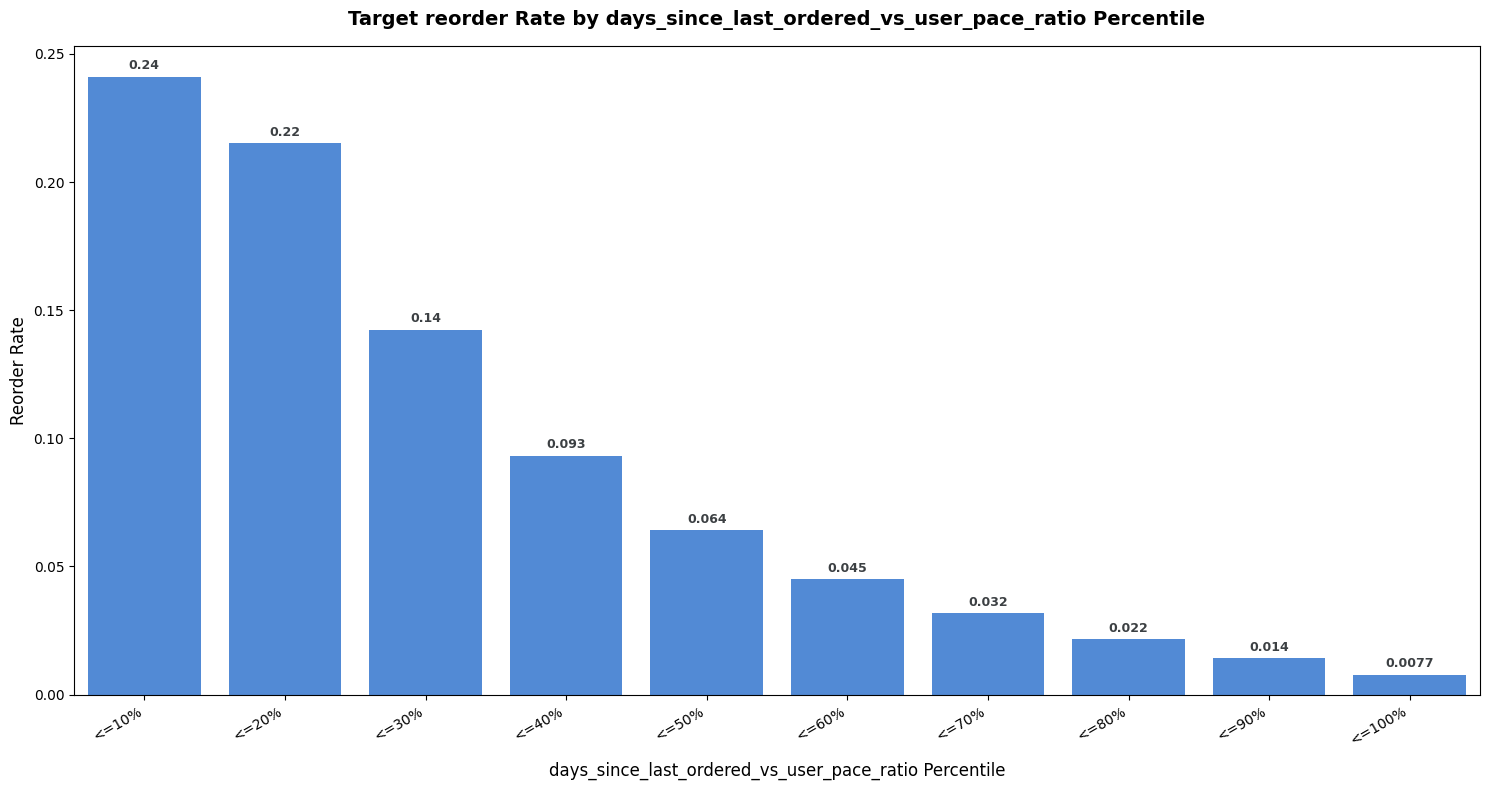

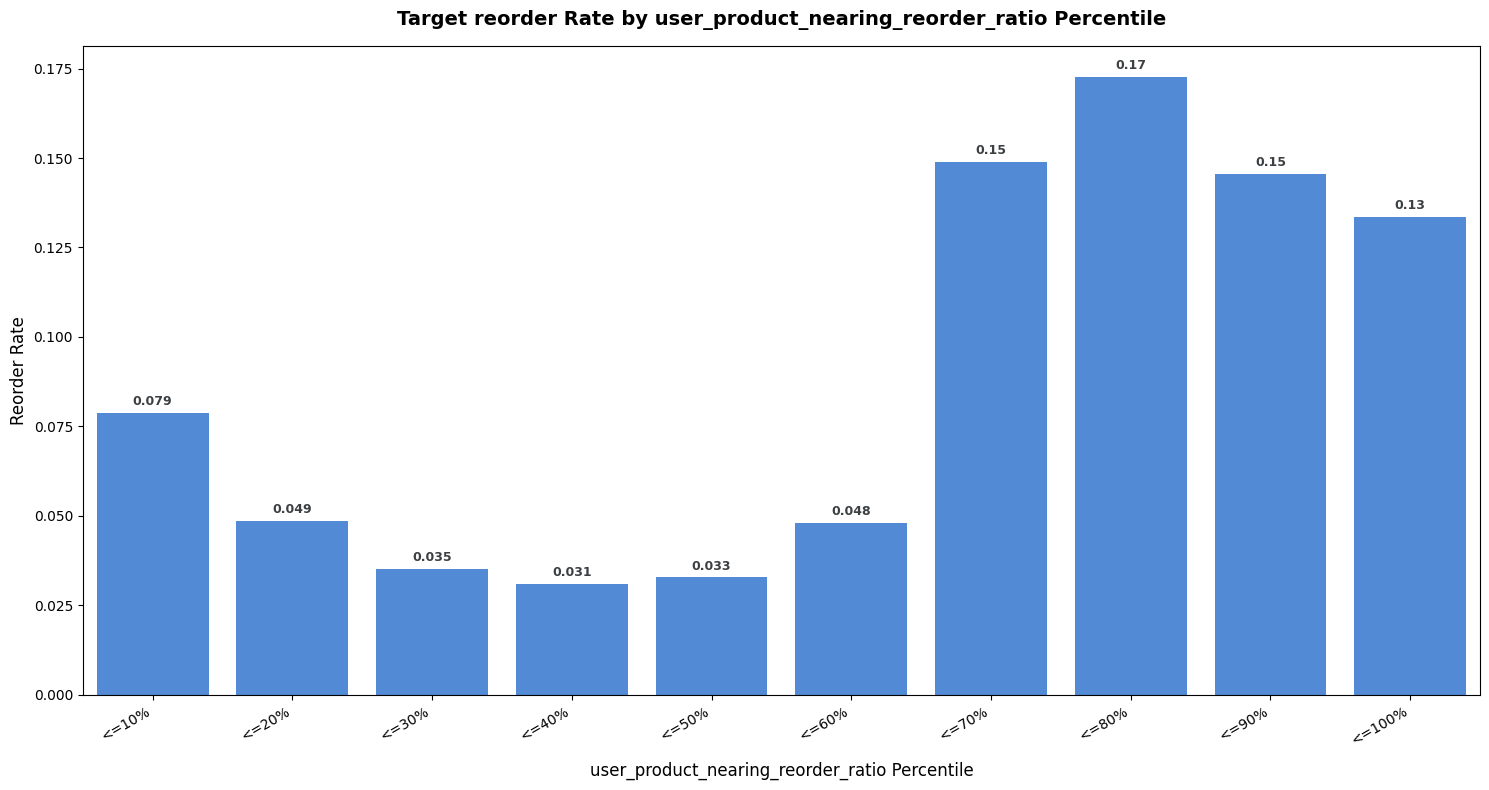

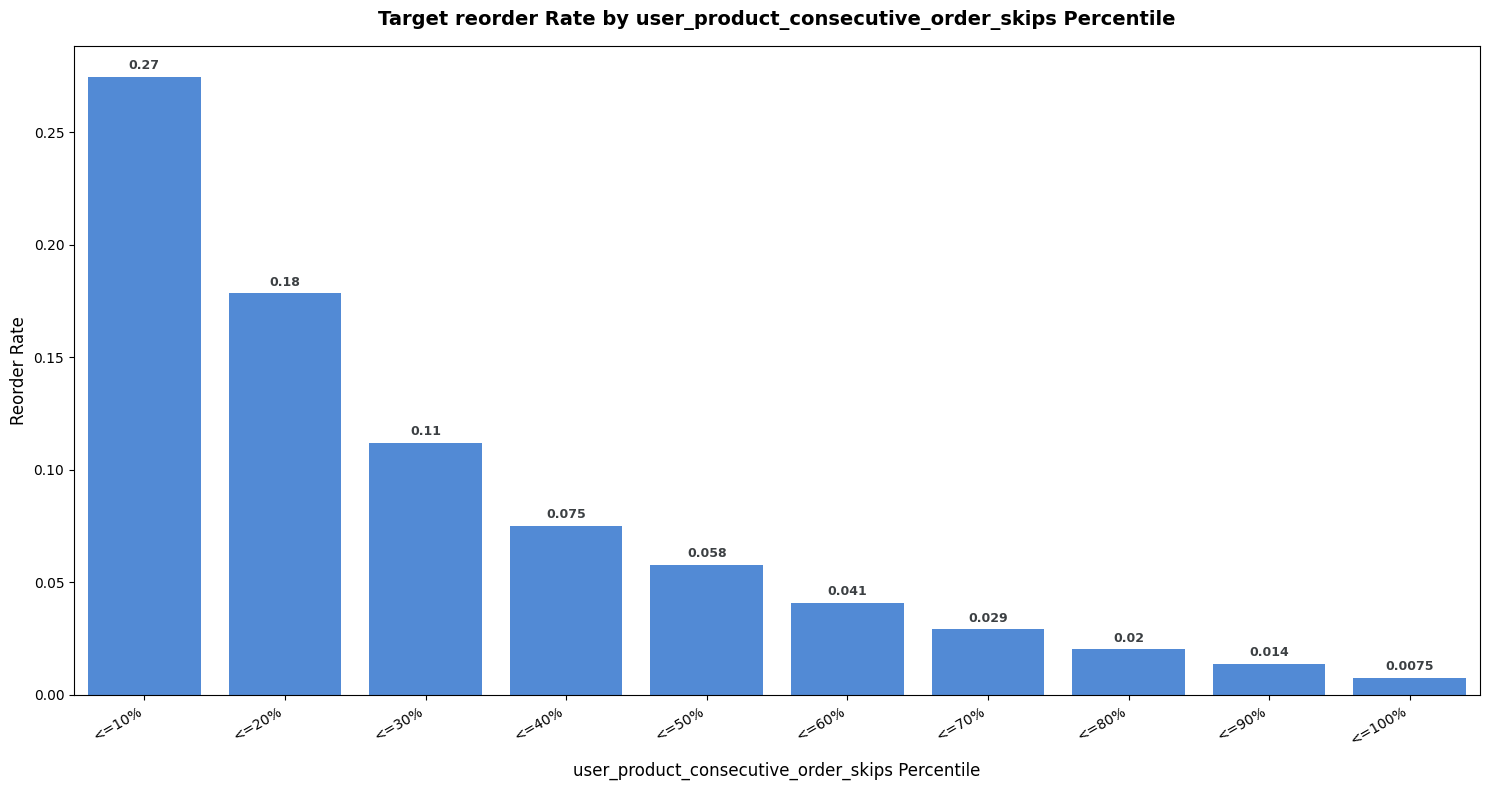

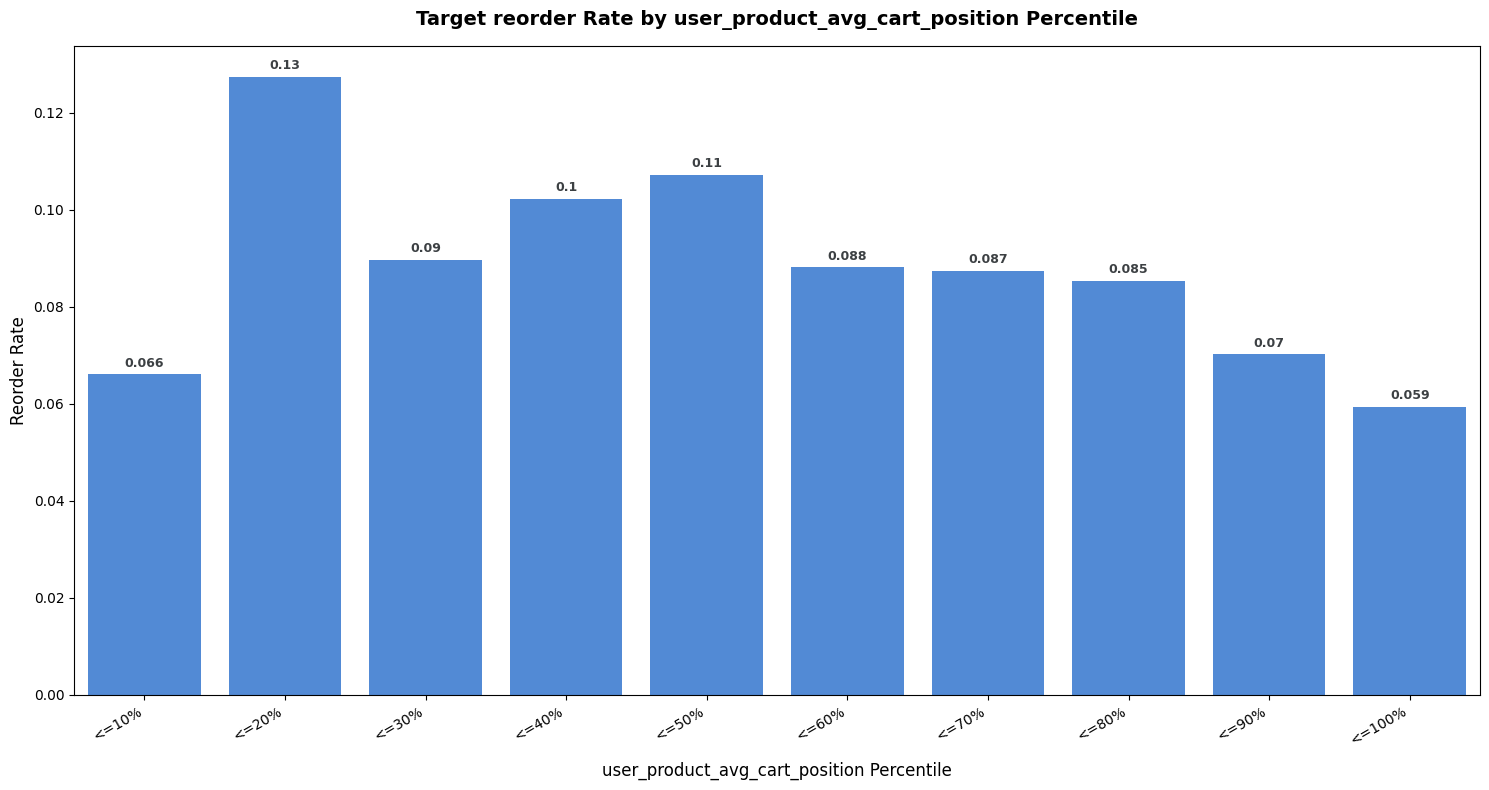

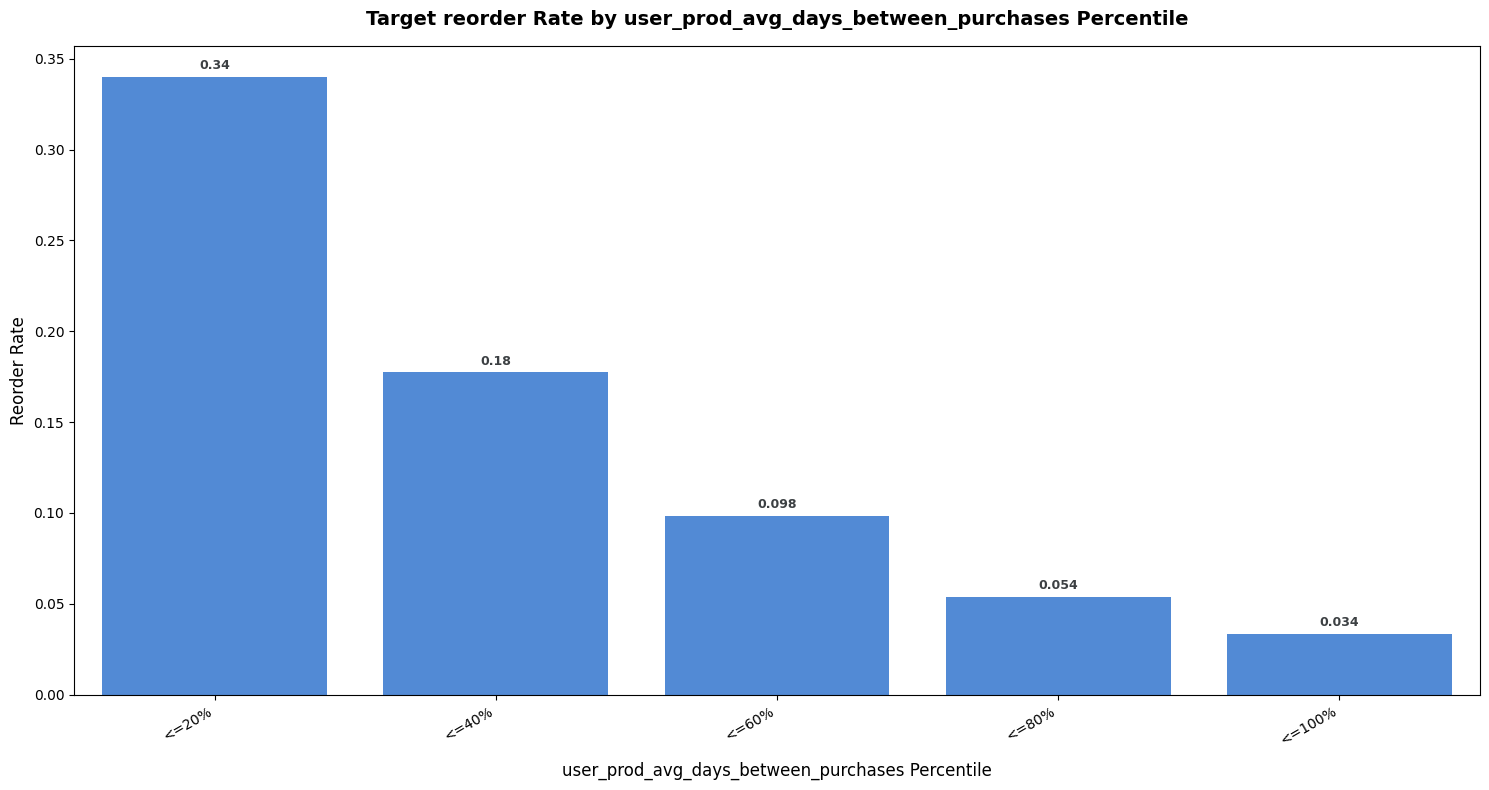

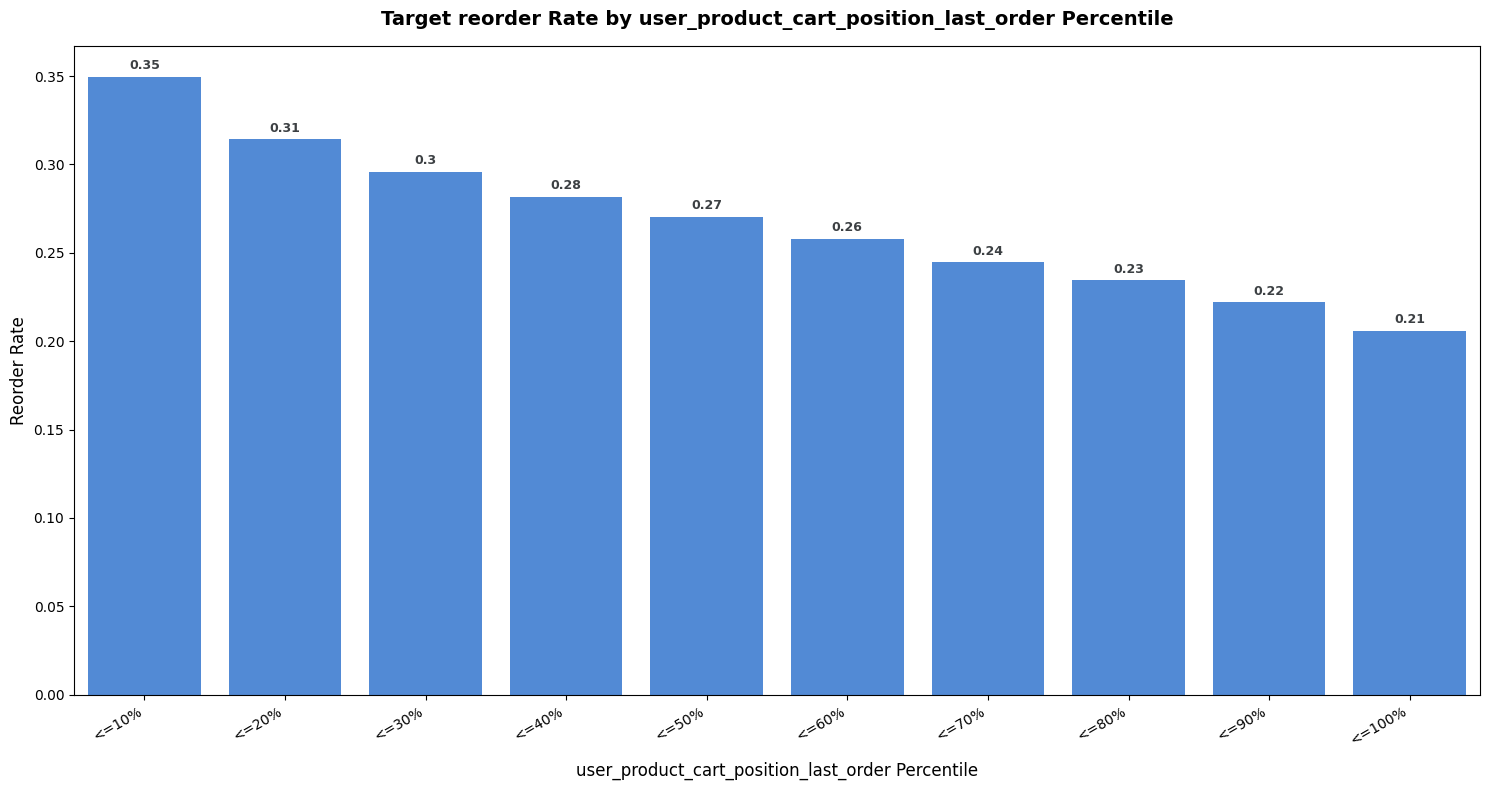

In [11]:
cols = [
    'days_since_last_ordered_vs_user_pace_ratio', 
    'user_product_nearing_reorder_ratio', 
    'user_product_consecutive_order_skips',
    'user_product_avg_cart_position',
    'user_prod_avg_days_between_purchases',
    'user_product_cart_position_last_order'
]

label = ['label_reordered']

#Due to binning before plotting, the full data set can be used for the bar plots.
#Create a copy to avoid manipulating the orignal data set. Keep only cols and label in the copy

select_cols = cols + label
bf_copy = bf_full[select_cols].copy()

# 3. Loop through columns and construct bar plot
for col in cols:
      
    bf_copy['bin_id'] = bpd.qcut(bf_copy[col], q = 10, labels=False, duplicates = 'drop')

    #Aggregate and convert to pandas df
    bf_agg = bf_copy.groupby(['bin_id']).agg(label_reordered = ('label_reordered', 'mean')).reset_index()
    df_bin_agg = bf_agg.to_pandas()
    
    #Sort values by bin_id
    df_bin_agg = df_bin_agg.sort_values(by='bin_id').reset_index(drop=True)
    
    #Get bin_label
    df_bin_agg['bin_id'] = (df_bin_agg['bin_id'] + 1) * 10
    
    if col == 'user_prod_avg_days_between_purchases':
        df_bin_agg['bin_id'] = df_bin_agg['bin_id'] * 2
    
    df_bin_agg['bin_label'] = "<=" + df_bin_agg['bin_id'].astype(str) +"%"

    #Create Plot
    plt.figure(figsize=(15, 8))
    
    ax = sns.barplot(
        x='bin_label', 
        y='label_reordered', 
        data=df_bin_agg, 
        color='#1a73e8',
        alpha=0.85
    )
    
    plt.title(f'Target reorder Rate by {col} Percentile', fontsize=14, pad=15, weight='bold')
    plt.xlabel(f'{col} Percentile', fontsize=12, labelpad=10)
    plt.ylabel('Reorder Rate', fontsize=12)
    plt.xticks(rotation = 30, ha="right")
    
    # Add data labels on top of each bar to make it scannable for recruiters
    for p in ax.patches:
        height = p.get_height()
        #if height > 0:  # Only label bins that contain data
        ax.annotate(f'{height:.2}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='center', 
                        xytext=(0, 8), 
                        textcoords='offset points', 
                        fontsize=9, weight='semibold', color='#3c4043')
            
    plt.tight_layout()
    plt.show()

<div style="background-color: #e6f4ea; border-left: 4px solid #137333; color: #137333; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>💡 Key Insights:</strong> 
    <ol class="modern-list"> 
        <li>A user with a product having a higher nearing re-order ratio indicates that product is more likely to be re-ordered. This makes sense as the nearing re-order ratio is determined based on a users historical pruchase cycle for a product. </li>
        <li>Higher consecutive order skips for a product indicates the product is less likely to be re-ordered.</li>
        <li>For a user product combination, lower average days between purchases indicates higher probability that the user will re-order that product</li>
</div></ol>

### 4. Correlation Heatmap

<div style="background-color: #e8f0fe; border-left: 4px solid #1a73e8; color: #1c3d5a; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>🛠️ Strategy & Insight:</strong> While tree-based models (like LightGBM and XGBoost) handle correlated features natively without breaking, identifying multicollinearity is still helpful for interpreting feature importance accurately and preventing redundant signals from dominating the splits.
</div>

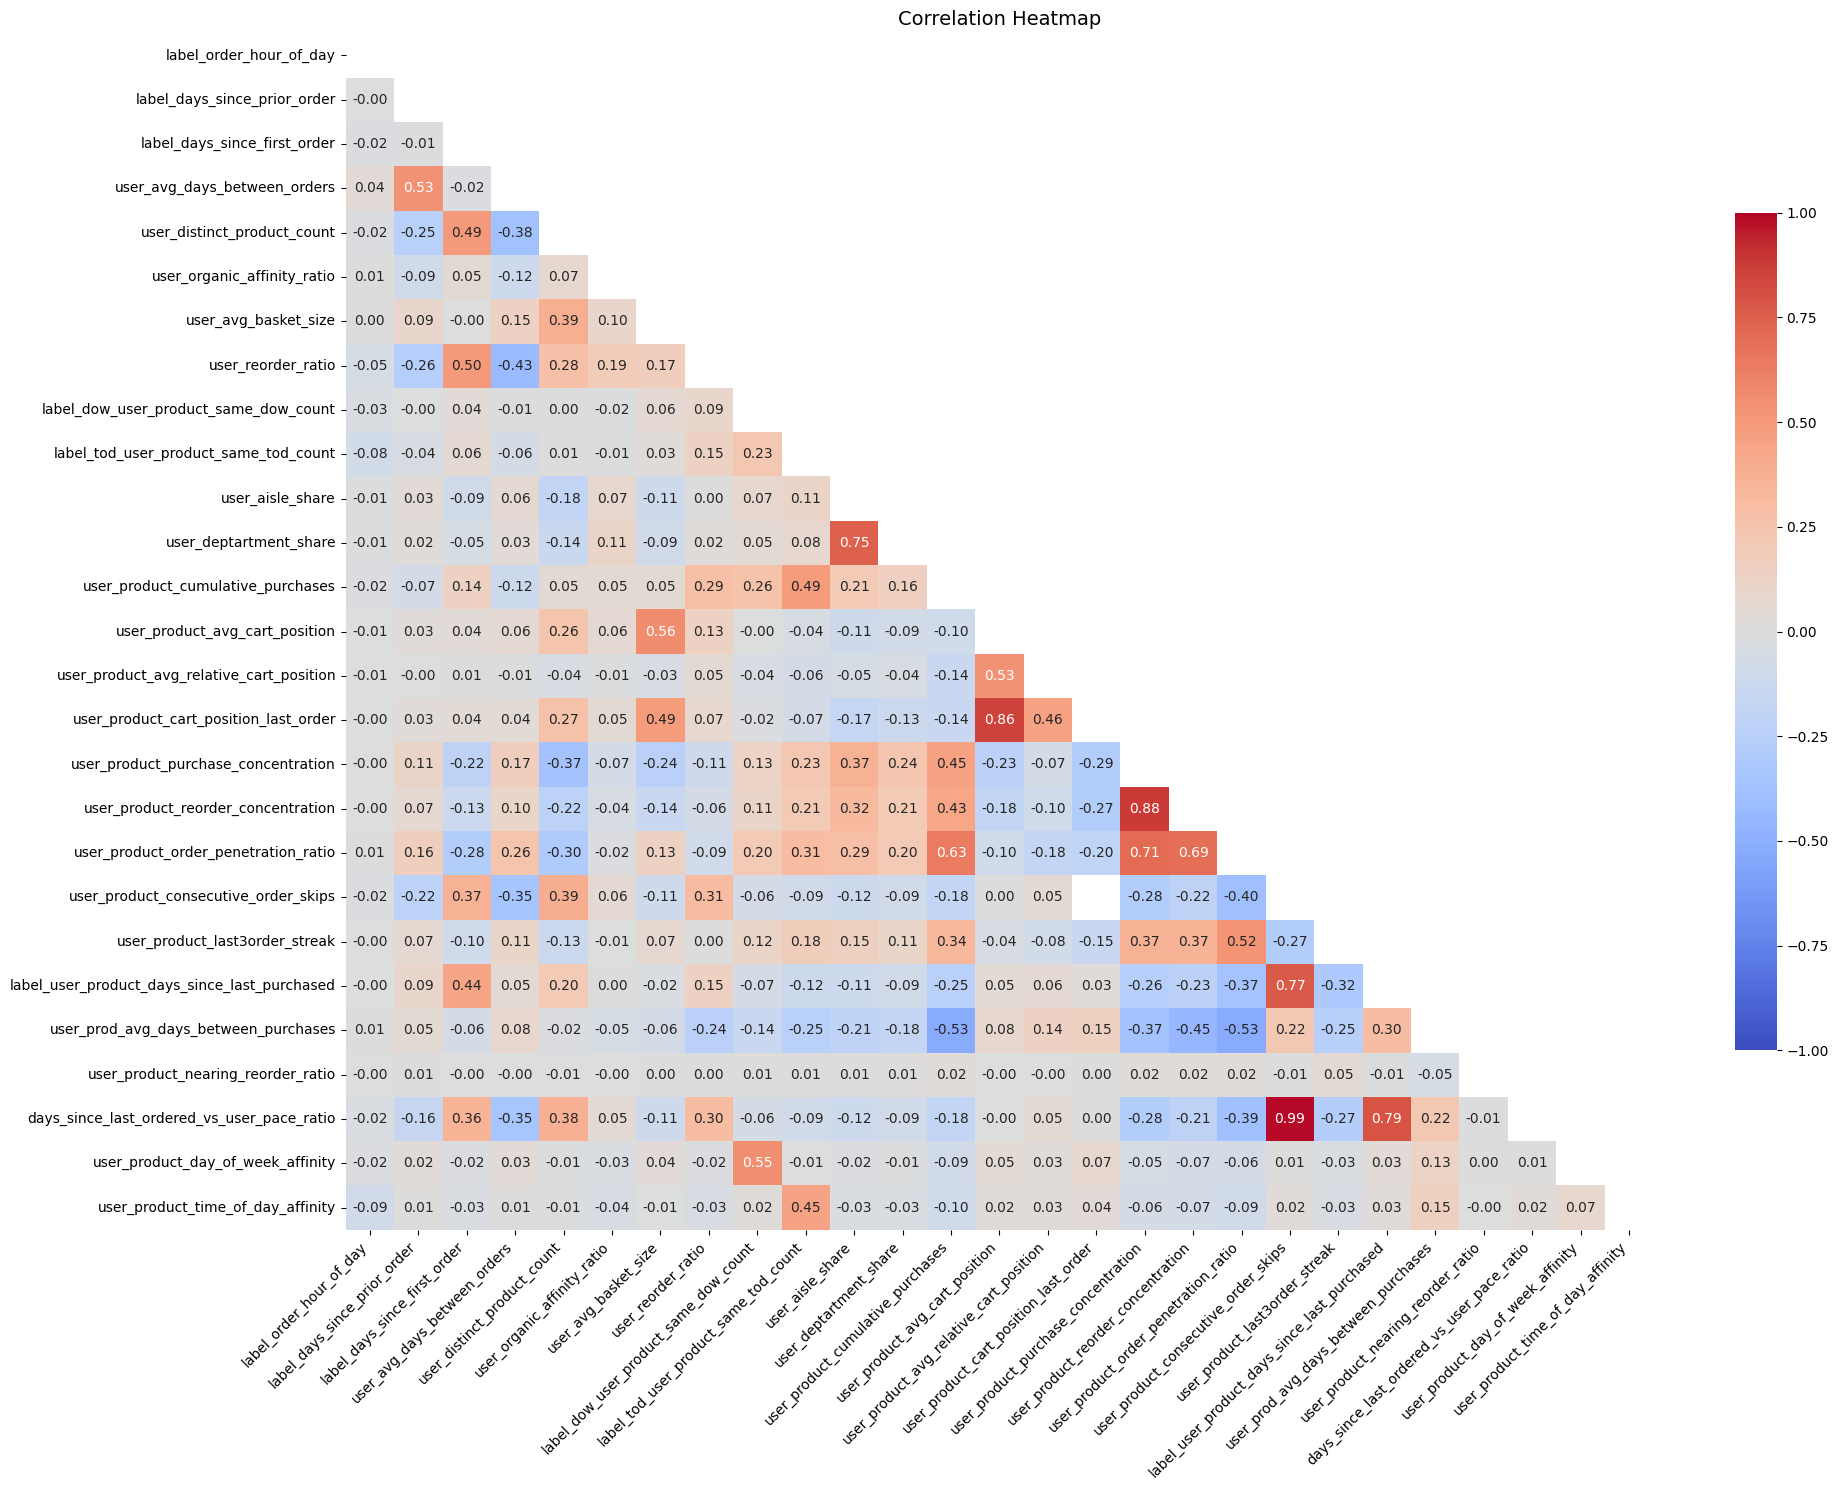

In [12]:
# Calculate correlations for all rows inside BigQuery compute engine

exclude_cols = ['user_id', 'label_order_id', 'label_order_number', 'candidate_product_id',
                'anchor_order_id', 'anchor_order_number', 'department_id', 'aisle_id',
                'label_time_of_day', 'label_reordered', 'anchor_days_since_first_order', 'label_order_dow']

cm = bf_full.drop(columns = exclude_cols).corr().to_pandas().astype(float)

# Plot full comprehensive correlation matrix landscape map
plt.figure(figsize=(20, 15))
mask = np.triu(np.ones_like(cm, dtype=bool))
sns.heatmap(cm, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, cbar_kws={"shrink": .7})
plt.title("Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


<div style="background-color: #e6f4ea; border-left: 4px solid #137333; color: #137333; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>💡 Key Insights:</strong> 
    <ol class="modern-list"> 
        <li>days_since_last_ordered_vs_user_pace_ratio is almost perfectly correlated with user_product_consecutive_order skips. days_since_last_ordered_vs_user_pace_ratio is the days since the user last ordered a product divided by the avg time between odrders. Thus it is equal to the number of orders consecutively skipped.</li>
        <li>days_since_last_ordered_vs_user_pace_ratio should be dropped for modeling. Additionally, anchor_days_since_first or label_days_since_first order should be dropped</li>
</div></ol>

### 4. LGBM Base Model Feature Screening 
Create LGBM lambdarank base model and use feature importance for feature screening

<div style="background-color: #e8f0fe; border-left: 4px solid #1a73e8; color: #1c3d5a; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>🛠️ Strategy:</strong> 
    <ol class="modern-list">
        <li>Downcast floats & ints to reduce memory usage </li>
        <li>One-hot encode categorical 'label_time_of_day'</li>
        <li>Exclude redundant columns & identifiers not needed for lgbm lambdaRank group array'</li>
</div></ol>

In [13]:
# Downcast float and integer data types
# Identify and cast all float64 columns to float32 & int64 to int32

df_full = bf_full.to_pandas()
float64_cols = df_full.select_dtypes(include=['float64']).columns
df_full[float64_cols] = df_full[float64_cols].astype('float32')

int64_cols = df_full.select_dtypes(include=['int64']).columns
df_full[int64_cols] = df_full[int64_cols].astype('Int32')

#Convert label_time_of_day pyarrow sting to object

arrow_table = pa.Table.from_pandas(df_full)
array_ltod = arrow_table['label_time_of_day']
df_full['label_time_of_day'] = array_ltod

df = pd.get_dummies(df_full, columns = ['label_time_of_day'])

#Exclude Cols not used by model (keep user_id and anchor_order_number)

exclude_cols = ['label_order_id', 'label_order_number', 'candidate_product_id',
               'anchor_days_since_first_order', 'anchor_order_id', 'department_id', 'aisle_id',
               'days_since_last_ordered_vs_user_pace_ratio', 
               ]

df = df.drop(columns=exclude_cols)

df.head(5)

,user_id,anchor_order_number,label_reordered,label_order_dow,label_order_hour_of_day,label_days_since_prior_order,label_days_since_first_order,user_avg_days_between_orders,user_distinct_product_count,user_organic_affinity_ratio,...,user_product_last3order_streak,label_user_product_days_since_last_purchased,user_prod_avg_days_between_purchases,user_product_nearing_reorder_ratio,user_product_day_of_week_affinity,user_product_time_of_day_affinity,label_time_of_day_afternoon,label_time_of_day_evening,label_time_of_day_morning,label_time_of_day_nighttime
0,94117,30,0,3,9,4,320,10.896552,127,0.498442,...,0,320,999.0,0.320320,0.000000,0.0,False,False,True,False
1,149547,27,0,2,7,8,234,8.692307,178,0.380577,...,0,97,999.0,0.097097,0.000000,1.0,False,False,True,False
2,183539,27,0,6,17,6,128,4.692307,54,0.000000,...,0,105,999.0,0.105105,1.000000,1.0,False,True,False,False
3,89079,15,1,1,17,7,80,5.214286,82,0.305556,...,3,7,7.3,0.958904,0.181818,0.0,False,True,False,False
4,87167,9,0,1,17,30,164,16.750000,51,0.024390,...,0,50,134.0,0.373134,0.000000,0.0,False,True,False,False


<div style="background-color: #e8f0fe; border-left: 4px solid #1a73e8; color: #1c3d5a; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>🛠️ Strategy:</strong> 
    <ol class="modern-list">
        <li>Perform train/val split. Ensure user groups are not split to avoid data leakage </li>
        <li>Create the arrays to tell the lgbm ranker the size of each order</li>
</div></ol>

In [14]:
#Get Train/Val splits
user_sample = pd.Series(df['user_id'].unique()).sample(frac = 0.8, random_state = 42)
df_train = df[df['user_id'].isin(user_sample)]
df_val = df[~df['user_id'].isin(user_sample)]


#Sort Values for ranking model
df_train = df_train.sort_values(by= ['user_id', 'anchor_order_number']).reset_index(drop = True)
df_val = df_val.sort_values(by= ['user_id', 'anchor_order_number']).reset_index(drop = True)

#Create features list
#exclude_cols = ['user_id']
#features_list = [col for col in df_train.columns if col not in exclude_cols]

#define x_train, y_train
x_train = df_train.drop(columns = ['label_reordered', 'user_id'])
y_train = pd.DataFrame(df_train['label_reordered'])
x_val = df_val.drop(columns = ['label_reordered', 'user_id'])
y_val = df_val['label_reordered']

#Define train and val size arrays to define groups for lgbm lambdaRank model
#Set sort = False to avoid group size misalignment and reduce sorting resource overhead
size_array_train = df_train.groupby(['user_id', 'anchor_order_number'], sort=False).size().to_numpy()
size_array_val = df_val.groupby(['user_id', 'anchor_order_number'], sort=False).size().to_numpy()

x_train.shape, y_val.shape

((15305230, 32), (3626621,))

<div style="background-color: #e8f0fe; border-left: 4px solid #1a73e8; color: #1c3d5a; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>🛠️ Strategy:</strong> 
    <ol class="modern-list">
        <li>Utilize ranking model as this aligns with widget business case to display the top 5 most likely items to be reordered</li>
        <li>Use ndcg as evaluation metric beacuse order matters due to natural eye reading pattern for widget display</li>
        <li>Utilize importance type gain to ensure feature importance is relevant for feature screening  </li>
        <li>Utilize gpu due to data size </li>
        <li>n_estimators capped at 1000 because early stopping is utilized for regularization</li>
        <li>Utilize 0.05 learning rate aimed at improving regularization in comparison to default learning rate of 0.1</li>
</div></ol>

In [15]:
#Create model instance
ranker_screening = lgb.LGBMRanker(
    objective="lambdarank",   #Utilize ranking model as this aligns with widget business case to display the top 5 most likely items to be reordered
    metric="ndcg",            #Use ndcg as evaluation metric (order matters here due to natural eye reading pattern for widget display)
    importance_type='gain',   #neccessary to obtain meaningful feature importance for screening
    device="gpu",             #leverage gpu for speed      
    n_estimators=1000,        #capped at 1000 since
    learning_rate=0.05        #Set lower default learning rate aimed at improving generalization
)

In [16]:
#Fit the model
ranker_screening.fit(x_train, y_train, group=size_array_train, eval_set=[(x_val, y_val)],
    eval_group=[size_array_val],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30), #Utilize early stopping for regularization. Set to 30 rounds for quick baseline
        lgb.log_evaluation(period=50) #prevent flooding of print statements
    ]
)

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 4807
[LightGBM] [Info] Number of data points in the train set: 15305230, number of used features: 32
[LightGBM] [Info] Using GPU Device: NVIDIA L4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 23 dense feature groups (350.31 MB) transferred to GPU in 0.251463 secs. 1 sparse feature groups
Training until validation scores don't improve for 30 rounds
[50]	valid_0's ndcg@1: 0.603986	valid_0's ndcg@2: 0.577776	valid_0's ndcg@3: 0.565026	valid_0's ndcg@4: 0.557551	valid_0's ndcg@5: 0.555097
[100]	valid_0's ndcg@1: 0.607029	valid_0's ndcg@2: 0.580506	valid_0's ndcg@3: 0.56689	valid_0's ndcg@4: 0.55982	valid_0's ndcg@5: 0.557437
[150]	valid_0's ndcg@1: 0.608186	valid_0's ndcg@2: 0.581633	valid_0's ndcg@3: 0.567912	valid_0's ndcg@4: 0.560776	valid_0's ndcg@5: 0.558186
[

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,'lambdarank'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


<div style="background-color: #e8f0fe; border-left: 4px solid #1a73e8; color: #1c3d5a; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>🛠️ Strategy:</strong> 
    <ol class="modern-list">
        <li>Calculate ndcg score to understand baseline performance</li>
        <li>ndcg@5 is used to align with business case</li>
        <li>To properly evaluate the model, ndcg@5 must be calculated iteratively on each order</li>
</div></ol>

In [17]:
#Calculate ndcg score to gain insight into baseline model performance

val_pred = ranker_screening.predict(x_val)
val_true = y_val

def calc_ndcg_at_5(val_pred, val_true):
    ndcg_score_df = pd.DataFrame({
        'user_id': df_val['user_id'],
        'anchor_order_number': df_val['anchor_order_number'],
        'label': val_true,
        'ranking_score': val_pred 
        })

    def process_order(order):
        reorders = order['label'].sum()
        if reorders <= 1: 
            return np.nan #If there are no reorders or 1 reorder, ignore this order (avoids division by 0, returning 0 and penalizing the model, meaningless metric when there is only 1 product)
            
        label = order['label'].values.reshape(1, -1) # reshape to 2d array for ndcg_score()
        ranking_score = order['ranking_score'].values.reshape(1, -1) # reshape to 2d array for ndcg_score()
        ndcg = ndcg_score(label, ranking_score, k=5) #set k=5 to look only at top 5 candidate products for reorder

        return ndcg
    
    results = ndcg_score_df.groupby(['user_id', 'anchor_order_number']).apply(process_order) #Pass each order to process_order function to calculate the ndcg score for each order individually
    results_df = pd.DataFrame(results.to_list(), columns = ['ndcg@5'])

    return results_df

results_df = calc_ndcg_at_5(val_pred, val_true)
results_df.mean()

ndcg@5    0.54097
dtype: float64

<div style="background-color: #e8f0fe; border-left: 4px solid #1a73e8; color: #1c3d5a; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>🛠️ Strategy:</strong> 
    <ol class="modern-list">
        <li>Identify feature importance</li>
        <li>Calulate cumulative percentage of importance from most important feature to least important feature</li>
        <li>Visualize feature importance</li>
        <li>Retain features that account for 99% of importance (feature level regularization)</li>
        <li>Save Final Feature list</li>
</div></ol>

In [18]:
feature_importance = pd.DataFrame({
    'feature': x_train.columns,
    'importance': ranker_screening.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance['cumulative_sum'] = feature_importance['importance'].cumsum()
feature_importance['cumulative_percentage'] = 100 * feature_importance['cumulative_sum'] / feature_importance['importance'].sum()
display(feature_importance)

,feature,importance,cumulative_sum,cumulative_percentage
24,user_prod_avg_days_between_purchases,3.674842e+06,3.674842e+06,57.252082
21,user_product_consecutive_order_skips,7.346673e+05,4.409510e+06,68.697807
20,user_product_order_penetration_ratio,6.091843e+05,5.018694e+06,78.188573
19,user_product_reorder_concentration,3.605056e+05,5.379199e+06,83.805058
23,label_user_product_days_since_last_purchased,2.342947e+05,5.613494e+06,87.455245
22,user_product_last3order_streak,1.768575e+05,5.790352e+06,90.210589
14,user_product_cumulative_purchases,1.473371e+05,5.937689e+06,92.506022
18,user_product_purchase_concentration,1.076025e+05,6.045291e+06,94.182412
25,user_product_nearing_reorder_ratio,7.166152e+04,6.116953e+06,95.298861
9,user_reorder_ratio,6.888519e+04,6.185838e+06,96.372055


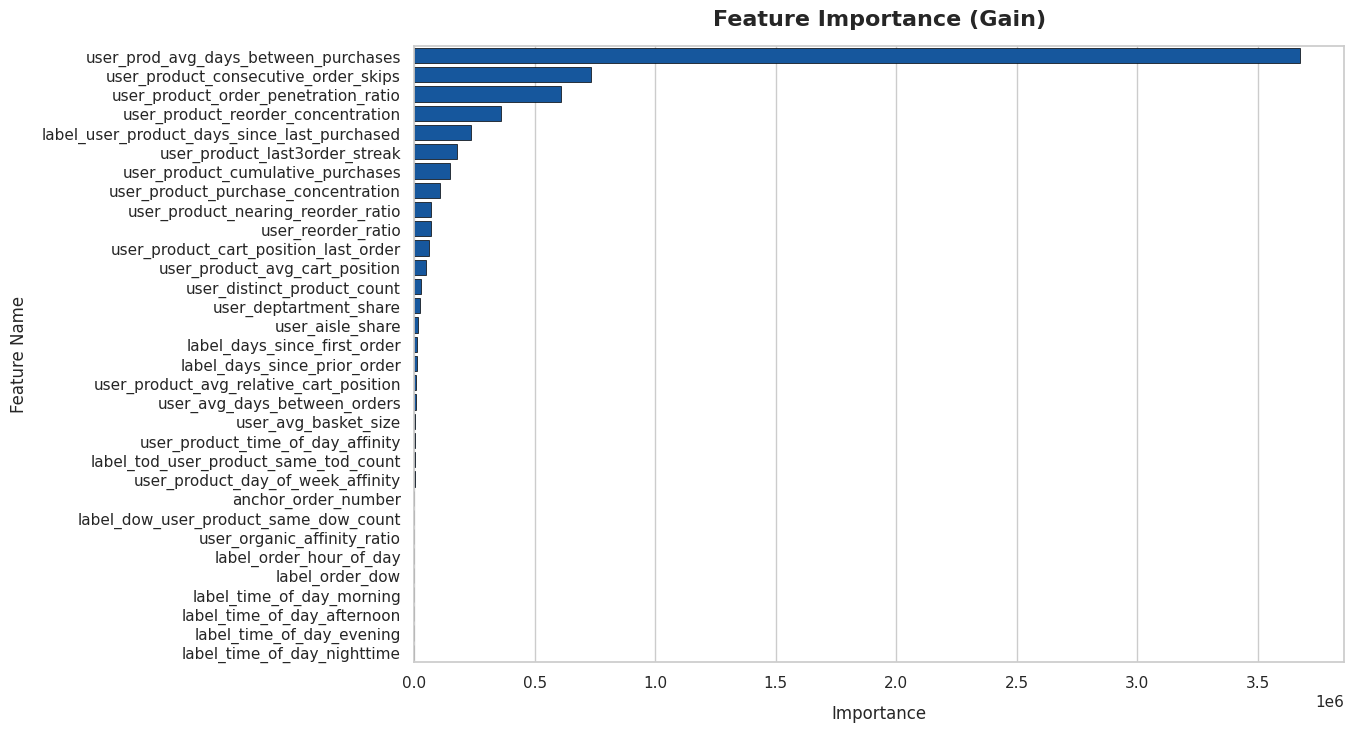

<Figure size 640x480 with 0 Axes>

In [19]:
# Barplot of feature importance
def plot_feature_importance(feature_importance):
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 8))
    corporate_blue = "#0056b3"

    # Create the barplot
    ax = sns.barplot(
    data=feature_importance, 
    x='importance', 
    y='feature', 
    color=corporate_blue,
    edgecolor="black", # Adds a subtle border to the bars
    linewidth=0.5
)

    plt.title("Feature Importance (Gain)", fontsize=16, fontweight="bold", pad=15)
    plt.xlabel("Importance", fontsize=12, fontweight="medium", labelpad=10)
    plt.ylabel("Feature Name", fontsize=12, fontweight="medium", labelpad=10)

    plt.show()

# Remove the top and right borders (spines) for a cleaner look
    sns.despine(top=True, right=True)

    return

plot_feature_importance(feature_importance)

<div style="background-color: #e6f4ea; border-left: 4px solid #137333; color: #137333; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>💡 Key Insight (Feature Importance):</strong> 
    <ul>
        <li><strong>Driving the Signal:</strong> The baseline model shows that a few core feature groups carry the bulk of the predictive power—specifically the timing metrics (like average days between purchases combined with days since last purchase), the historical streak trackers, and the concentration and penetration ratios.</li>
        <li><strong>Feature Screening Opportunity:</strong> Because the signal is heavily driven by these key features, we have a clear opportunity to screen out noisy and low-value features. This will speed up training performance on the large dataset and prevent noise from potentially confusing the model.</li>
        <li><strong>Model Validation:</strong> The feature importance, cumulative gain, and strong baseline ndcg@5 score provide confidence to move forward with modeling.</li>
    </ul>
</div>

In [20]:
exclude_list = ['label_days_since_prior_order', 'label_days_since_first_order', 'user_product_avg_relative_cart_position', 'user_avg_days_between_orders', 'user_avg_basket_size', 'label_tod_user_product_same_tod_count',
                'user_product_time_of_day_affinity', 'user_product_day_of_week_affinity', 'anchor_order_number', 'label_dow_user_product_same_dow_count', 'user_organic_affinity_ratio',
                'label_order_hour_of_day', 'label_order_dow', 'label_time_of_day_afternoon', 'label_time_of_day_evening', 'label_time_of_day_morning', 'label_time_of_day_nighttime']

final_feature_df = feature_importance[~feature_importance['feature'].isin(exclude_list)]
final_feature_list = final_feature_df['feature'].tolist()

final_feature_list

['user_prod_avg_days_between_purchases',
 'user_product_consecutive_order_skips',
 'user_product_order_penetration_ratio',
 'user_product_reorder_concentration',
 'label_user_product_days_since_last_purchased',
 'user_product_last3order_streak',
 'user_product_cumulative_purchases',
 'user_product_purchase_concentration',
 'user_product_nearing_reorder_ratio',
 'user_reorder_ratio',
 'user_product_cart_position_last_order',
 'user_product_avg_cart_position',
 'user_distinct_product_count',
 'user_deptartment_share',
 'user_aisle_share']

In [21]:
with open("/home/jupyter/Instacart_Reorder_Engine/final_feature_list", "w") as f:
    for item in final_feature_list:
        f.write(f"{item}\n")

<div style="background-color: #e8f0fe; border-left: 4px solid #1a73e8; color: #1c3d5a; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>🛠️ Strategy:</strong> Retrain model with trimmed features and verify no significant performance decrease</li>
</div>

In [22]:


exclude_list = ['label_days_since_prior_order', 'label_days_since_first_order', 'user_product_avg_relative_cart_position', 'user_avg_days_between_orders', 'user_avg_basket_size', 'label_tod_user_product_same_tod_count',
                'user_product_time_of_day_affinity', 'user_product_day_of_week_affinity', 'anchor_order_number', 'label_dow_user_product_same_dow_count', 'user_organic_affinity_ratio',
                'label_order_hour_of_day', 'label_order_dow', 'label_time_of_day_afternoon', 'label_time_of_day_evening', 'label_time_of_day_morning', 'label_time_of_day_nighttime']

x_train = x_train.drop(columns = exclude_list)
x_val = x_val.drop(columns = exclude_list)


#Fit the model
ranker_screening.fit(x_train, y_train, group=size_array_train, eval_set=[(x_val, y_val)],
    eval_group=[size_array_val],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30), #Utilize early stopping for regularization. Set to 30 rounds for quick baseline
        lgb.log_evaluation(period=50) #prevent flooding of print statements
    ]
)

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 3018
[LightGBM] [Info] Number of data points in the train set: 15305230, number of used features: 15
[LightGBM] [Info] Using GPU Device: NVIDIA L4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 13 dense feature groups (233.54 MB) transferred to GPU in 0.136614 secs. 1 sparse feature groups
Training until validation scores don't improve for 30 rounds
[50]	valid_0's ndcg@1: 0.603772	valid_0's ndcg@2: 0.577615	valid_0's ndcg@3: 0.564588	valid_0's ndcg@4: 0.557574	valid_0's ndcg@5: 0.55488
[100]	valid_0's ndcg@1: 0.606793	valid_0's ndcg@2: 0.58022	valid_0's ndcg@3: 0.566634	valid_0's ndcg@4: 0.559704	valid_0's ndcg@5: 0.557215
[150]	valid_0's ndcg@1: 0.607222	valid_0's ndcg@2: 0.580693	valid_0's ndcg@3: 0.56735	valid_0's ndcg@4: 0.560466	valid_0's ndcg@5: 0.557975
Ea

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,'lambdarank'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [25]:
#Calc ndcg@5
val_pred = ranker_screening.predict(x_val)
val_true = y_val

results_df = calc_ndcg_at_5(val_pred, val_true)
results_df.mean()

ndcg@5    0.540393
dtype: float64

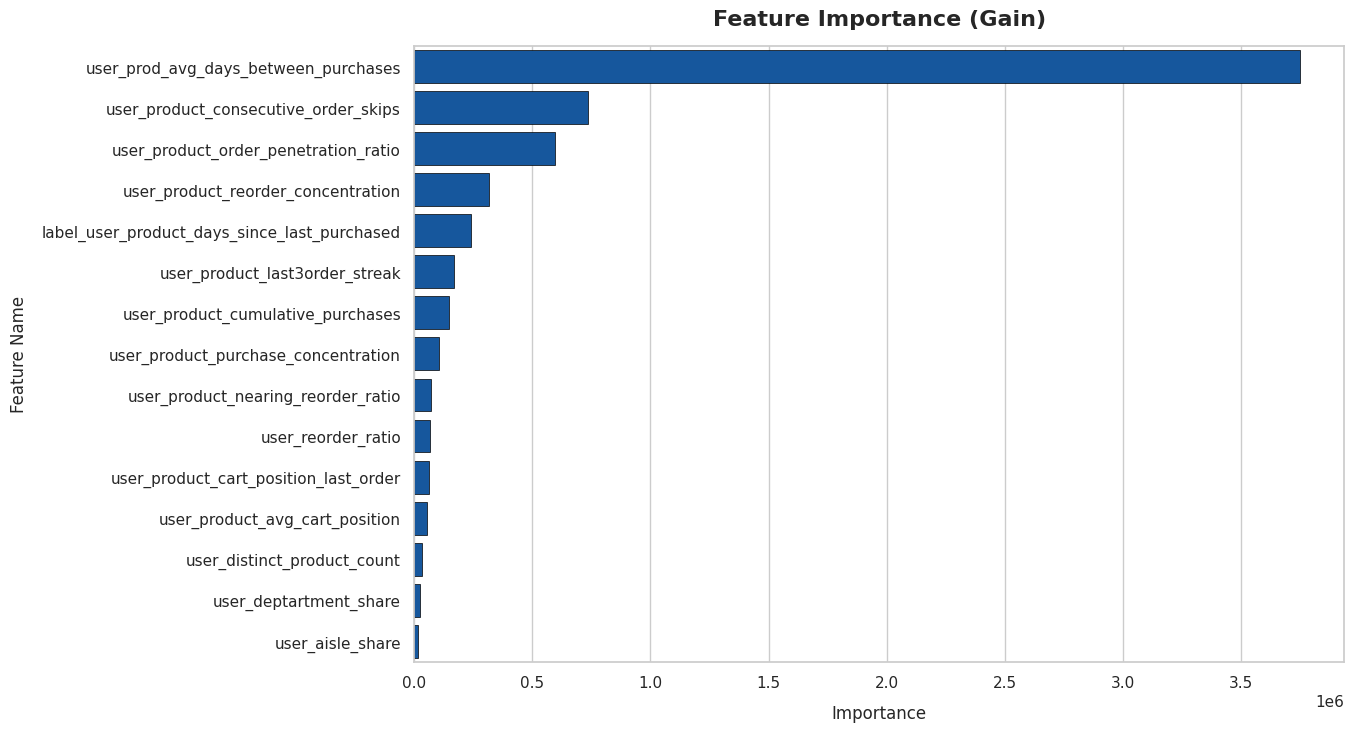

<Figure size 640x480 with 0 Axes>

In [26]:
feature_importance = pd.DataFrame({
    'feature': x_train.columns,
    'importance': ranker_screening.feature_importances_
}).sort_values(by='importance', ascending=False)

plot_feature_importance(feature_importance)

<div style="background-color: #e6f4ea; border-left: 4px solid #137333; color: #137333; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>💡 Key Insight (Feature Importance):</strong> 
    <ul>
        <li><strong>Trimming Impact:</strong> Trimming down the feature list caused no significant drop in model performance and feature importance remained consistent, providing confidence to move forward with the smaller feature list.</li>
    </ul>
</div>